<a href="https://colab.research.google.com/github/Rafly-Codes/analisis-ecommerce/blob/main/KAGGLE_PAK_ARIFIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Install the Kaggle API client

First, we need to install the Kaggle API client library. This library allows you to interact with Kaggle's API to download datasets.

In [ ]:
pip install kaggle

### 2. Authenticate with Kaggle

To download datasets, you need to authenticate with your Kaggle API key.

1. Go to your Kaggle account page: [https://www.kaggle.com/me/account](https://www.kaggle.com/me/account)
2. Under the 'API' section, click 'Create New API Token'. This will download a `kaggle.json` file.
3. Upload this `kaggle.json` file to your Colab environment. You can do this by clicking the 'Files' icon on the left sidebar (folder icon) and then the 'Upload' icon.

Alternatively, you can save your Kaggle username and API key as Colab secrets:

1. Open the 'Secrets' panel (key icon) on the left sidebar.
2. Add two new secrets: `KAGGLE_USERNAME` and `KAGGLE_KEY`, with your respective credentials.

I will generate code that uses the `kaggle.json` file. If you prefer to use secrets, you'll need to modify this step accordingly.

In [ ]:
import os

# Create a .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Move the uploaded kaggle.json to the .kaggle directory
# Make sure you have uploaded kaggle.json to the Colab environment first
# If you're using secrets, you would set KAGGLE_USERNAME and KAGGLE_KEY environment variables instead.
!mv kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle authentication setup complete.")

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle authentication setup complete.


### 3. Find and Download a Dataset

Now you can download a dataset. You'll need the dataset's identifier from Kaggle. For example, the 'Titanic - Machine Learning from Disaster' dataset has the identifier `titanic`. You can find this on the dataset's Kaggle page in the URL (e.g., `kaggle.com/c/titanic`).

**Please replace `'your-dataset-id'` with the actual ID of the Kaggle dataset you want to use.** For competitions, it's `kaggle.com/c/your-competition-id` and for datasets, it's `kaggle.com/datasets/owner/dataset-name`.

In [ ]:
# Replace 'your-dataset-id' with the actual dataset identifier from Kaggle
# For example: 'titanic'
# If it's a dataset, the format is 'owner/dataset-name', e.g., 'fedesoriano/stroke-prediction-dataset'
# If it's a competition, it's just the competition name, e.g., 'titanic'

dataset_id = 'your-dataset-id' # <--- IMPORTANT: Change this to your desired dataset ID!

# Check if the dataset ID is for a competition or a regular dataset
# Kaggle CLI command to download a dataset
# For competition: !kaggle competitions download -c {dataset_id}
# For dataset: !kaggle datasets download -d {dataset_id}

# Example for a competition (e.g., 'titanic')
# !kaggle competitions download -c {dataset_id}

# Example for a public dataset (e.g., 'fedesoriano/stroke-prediction-dataset')
# You might need to adjust the command based on whether it's a competition or a dataset.
print(f"Attempting to download dataset: {dataset_id}")
!kaggle datasets download -d {dataset_id}

print("Dataset downloaded. You might need to unzip it if it's a .zip file.")

Attempting to download dataset: your-dataset-id
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
Dataset downloaded. You might need to unzip it if it's a .zip file.


### 4. Unzip the Dataset (if necessary)

Many Kaggle datasets are downloaded as `.zip` files. You'll need to unzip them to access the CSV or other data files.

In [ ]:
# Replace 'your-dataset-file.zip' with the actual name of the downloaded zip file
# You can use `!ls` to see the downloaded files.

zip_file_name = 'your-dataset-id.zip' # <--- IMPORTANT: Change this to the downloaded zip file name!

# Ensure the zip file exists before trying to unzip
if os.path.exists(zip_file_name):
    print(f"Unzipping {zip_file_name}...")
    !unzip -o {zip_file_name}
    print("Unzipping complete.")
else:
    print(f"Error: {zip_file_name} not found. Please check the dataset ID and downloaded file name.")

# List files in the current directory to see extracted files
!ls

Error: your-dataset-id.zip not found. Please check the dataset ID and downloaded file name.
sample_data


### 5. Load the Data into a Pandas DataFrame

Finally, load the data (e.g., a CSV file) into a pandas DataFrame for analysis.

In [ ]:
import pandas as pd

df = pd.read_csv('datasets e commerce.csv')

# Isi yang kosong pakai rumus
df['Total_Sales'] = df['Total_Sales'].fillna(df['Quantity'] * df['Price_Per_Unit'])

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [ ]:
top_category = df.groupby('Product_Category')['Total_Sales'].sum().sort_values(ascending=False)

top_category.plot(kind='bar')
plt.title('Kategori Paling Laris')
plt.show()

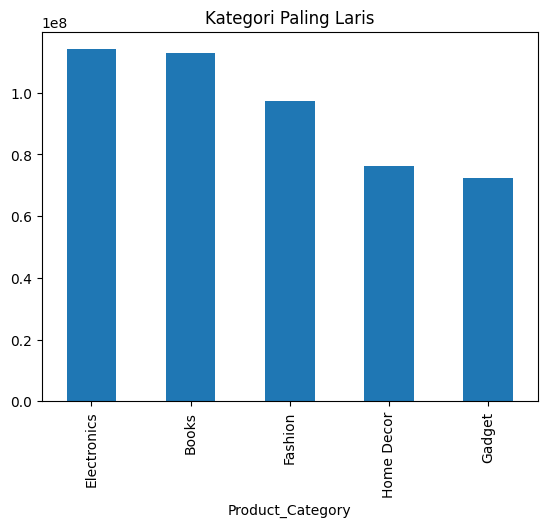

In [ ]:
top_category = df.groupby('Product_Category')['Total_Sales'].sum().sort_values(ascending=False)

top_category.plot(kind='bar')
plt.title('Kategori Paling Laris')
plt.show()

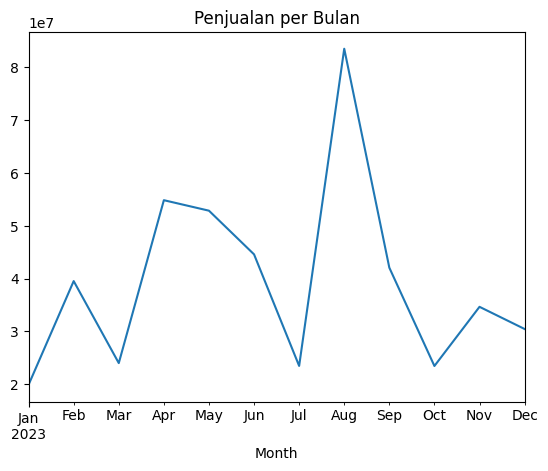

In [ ]:
df['Month'] = df['Order_Date'].dt.to_period('M')

monthly = df.groupby('Month')['Total_Sales'].sum()

monthly.plot(kind='line')
plt.title('Penjualan per Bulan')
plt.show()

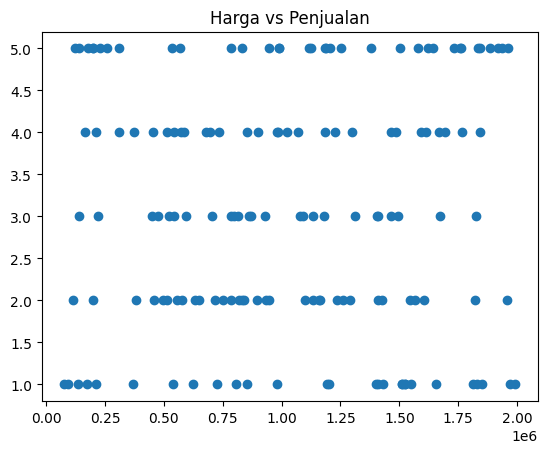

In [ ]:
plt.scatter(df['Price_Per_Unit'], df['Quantity'])
plt.title('Harga vs Penjualan')
plt.show()

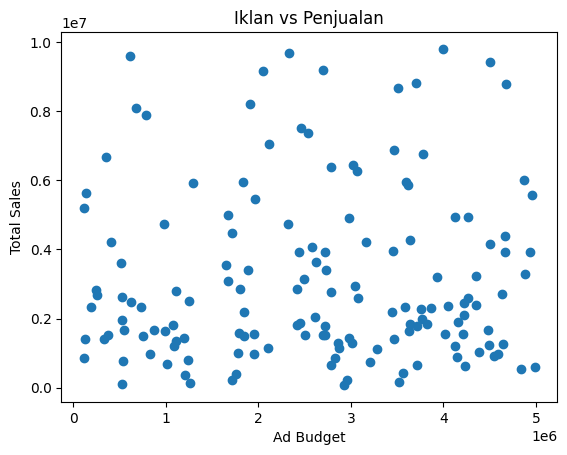

In [ ]:
plt.scatter(df['Ad_Budget'], df['Total_Sales'])
plt.xlabel('Ad Budget')
plt.ylabel('Total Sales')
plt.title('Iklan vs Penjualan')
plt.show()

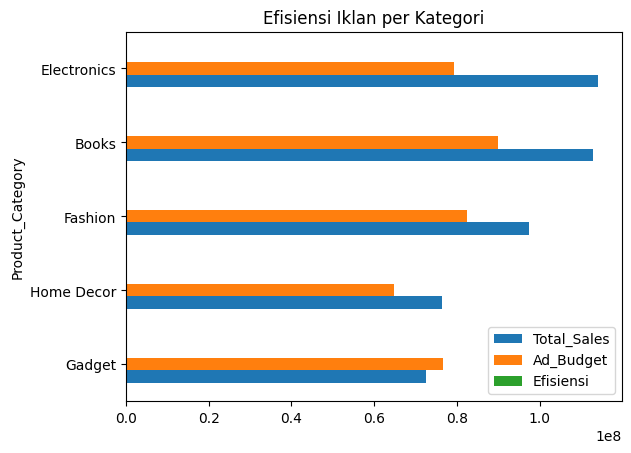

In [ ]:
category = df.groupby('Product_Category').agg({
    'Total_Sales': 'sum',
    'Ad_Budget': 'sum'
})

category['Efisiensi'] = category['Total_Sales'] / category['Ad_Budget']

category.sort_values('Efisiensi').plot(kind='barh')
plt.title('Efisiensi Iklan per Kategori')
plt.show()

In [ ]:
median_ads = df['Ad_Budget'].median()

high = df[df['Ad_Budget'] > median_ads]
low = df[df['Ad_Budget'] <= median_ads]

print("Iklan tinggi:", high['Total_Sales'].mean())
print("Iklan rendah:", low['Total_Sales'].mean())

Iklan tinggi: 3079293.3333333335
Iklan rendah: 3231280.0


In [ ]:
avg_price = df['Price_Per_Unit'].mean()

produk_gagal = df[
    (df['Price_Per_Unit'] > avg_price) &
    (df['Quantity'] < df['Quantity'].mean())
]

produk_gagal[['Product_Category','Price_Per_Unit','Quantity']]

,Product_Category,Price_Per_Unit,Quantity
4,Home Decor,1820000.0,2
7,Gadget,1431000.0,1
10,Electronics,1425000.0,2
16,Gadget,1164000.0,2
17,Home Decor,1495000.0,3
18,Home Decor,1546000.0,2
19,Books,1654000.0,1
26,Gadget,1080000.0,3
29,Gadget,1957000.0,2
30,Books,1134000.0,3


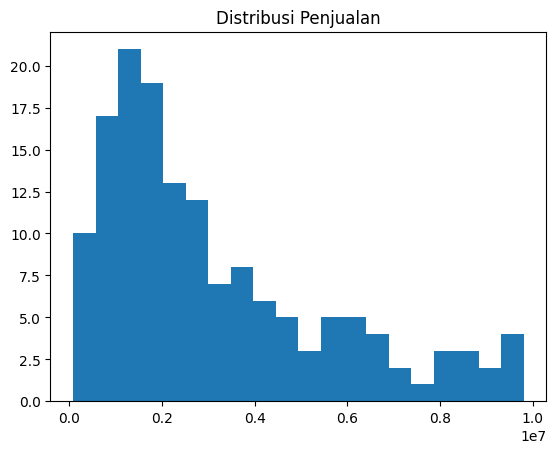

In [ ]:
plt.hist(df['Total_Sales'], bins=20)
plt.title('Distribusi Penjualan')
plt.show()

In [ ]:
import pandas as pd

# Replace 'your-data-file.csv' with the actual name of the CSV file inside the dataset
csv_file_name = 'your-data-file.csv' # <--- IMPORTANT: Change this to the actual CSV file name!

if os.path.exists(csv_file_name):
    df = pd.read_csv(csv_file_name)
    print(f"Data loaded from {csv_file_name} successfully!")
    display(df.head())
else:
    print(f"Error: {csv_file_name} not found. Please check the extracted file names.")